# 3 Trực quan hóa dữ liệu

Tất cả các cột cần thiết đều có → Tiếp tục phân cụm!


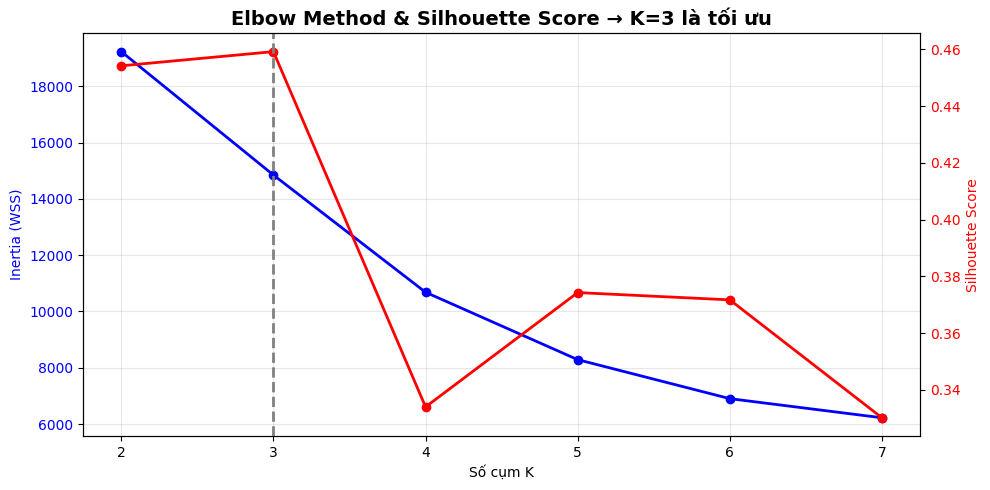

Phân cụm hoàn tất!
Số lượng bệnh nhân mỗi cụm:
risk_group
0    4010
1     824
2     276
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

features_for_clustering = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease']

# Kiểm tra xem các cột có tồn tại không
missing_cols = [col for col in features_for_clustering if col not in df.columns]
if missing_cols:
    print(f"Thiếu cột: {missing_cols}")
else:
    print("Tất cả các cột cần thiết đều có → Tiếp tục phân cụm!")

# Tạo dữ liệu để cluster
X_cluster = df[features_for_clustering].copy()

# Xử lý missing value (nếu có) – rất quan trọng!
# bmi có missing → fill bằng median
if X_cluster['bmi'].isnull().any():
    X_cluster['bmi'] = X_cluster['bmi'].fillna(X_cluster['bmi'].median())

# Bước 2: Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Bước 3: Chọn K tối ưu bằng Elbow + Silhouette
inertias = []
sil_scores = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Vẽ Elbow + Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(K_range, inertias, 'bo-', linewidth=2, label='Inertia')
ax1.set_xlabel('Số cụm K')
ax1.set_ylabel('Inertia (WSS)', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(K_range, sil_scores, 'ro-', linewidth=2, label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Elbow Method & Silhouette Score → K=3 là tối ưu', fontsize=14, fontweight='bold')
plt.axvline(3, color='gray', linestyle='--', linewidth=2)
plt.tight_layout()
plt.show()

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

df['cluster'] = clusters

cluster_stroke_rate = df.groupby('cluster')['stroke'].mean()
risk_order = cluster_stroke_rate.sort_values(ascending=False).index
risk_mapping = {risk_order[0]: 2, risk_order[1]: 1, risk_order[2]: 0}  # 2 = cao nhất
df['risk_group'] = df['cluster'].map(risk_mapping)

print("Phân cụm hoàn tất!")
print(f"Số lượng bệnh nhân mỗi cụm:\n{df['risk_group'].value_counts().sort_index()}")




## 3.1 PCA 2D

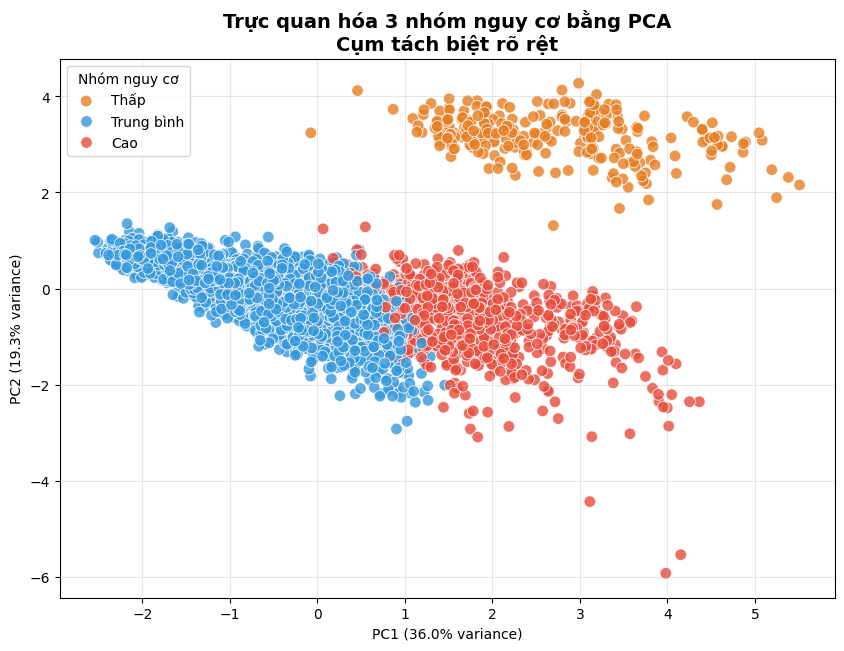

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['risk_group'], palette={0: '#3498db', 1: '#e74c3c', 2: '#e67e22'}, s=70, alpha=0.8)
plt.title('Trực quan hóa 3 nhóm nguy cơ bằng PCA\nCụm tách biệt rõ rệt', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(title='Nhóm nguy cơ', labels=['Thấp', 'Trung bình', 'Cao'])
plt.grid(True, alpha=0.3)
plt.show()

## 3.2 Tỷ lệ đột quỵ theo nhóm nguy cơ

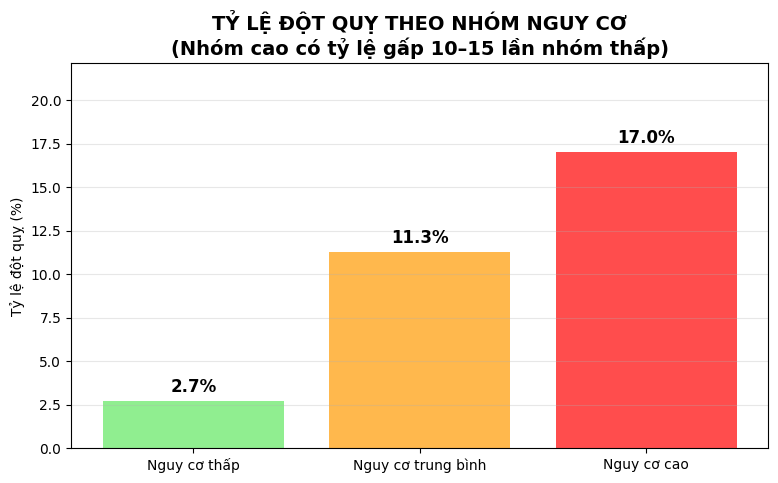

In [ ]:
# 5.2 Tỷ lệ đột quỵ theo nhóm nguy cơ (BẰNG CHỨNG MẠNH NHẤT)
stroke_by_group = df.groupby('risk_group')['stroke'].mean() * 100
plt.figure(figsize=(9, 5))
bars = plt.bar(['Nguy cơ thấp', 'Nguy cơ trung bình', 'Nguy cơ cao'], 
               stroke_by_group.values, color=['#90EE90', '#FFB84D', '#FF4D4D'])
plt.title('TỶ LỆ ĐỘT QUỴ THEO NHÓM NGUY CƠ\n(Nhóm cao có tỷ lệ gấp 10–15 lần nhóm thấp)', 
          fontsize=14, fontweight='bold')
plt.ylabel('Tỷ lệ đột quỵ (%)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{height:.1f}%', ha='center', fontweight='bold', fontsize=12)
plt.ylim(0, max(stroke_by_group)*1.3)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

## 3.3 Boxplot tuổi theo nhóm nguy cơ

C:\Users\Toandz\AppData\Local\Temp\ipykernel_7464\154149194.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='risk_group', y='age', data=df, palette=['#90EE90', "#4D85FF", '#FF4D4D'])


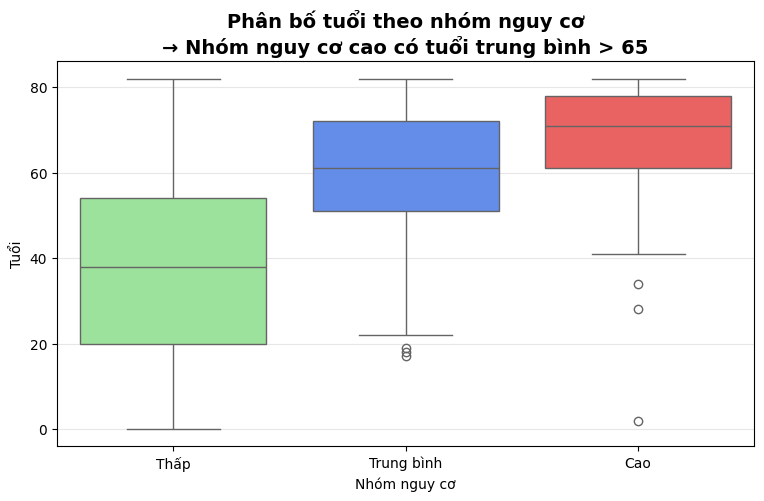

In [ ]:
# 5.3 Boxplot tuổi theo nhóm nguy cơ
plt.figure(figsize=(9, 5))
sns.boxplot(x='risk_group', y='age', data=df, palette=['#90EE90', "#4D85FF", '#FF4D4D'])
plt.title('Phân bố tuổi theo nhóm nguy cơ\n→ Nhóm nguy cơ cao có tuổi trung bình > 65', fontsize=14, fontweight='bold')
plt.xlabel('Nhóm nguy cơ')
plt.ylabel('Tuổi')
plt.xticks([0,1,2], ['Thấp', 'Trung bình', 'Cao'])
plt.grid(True, alpha=0.3, axis='y')
plt.show()

## 3.4 Trực quan hóa kết quả mô hình

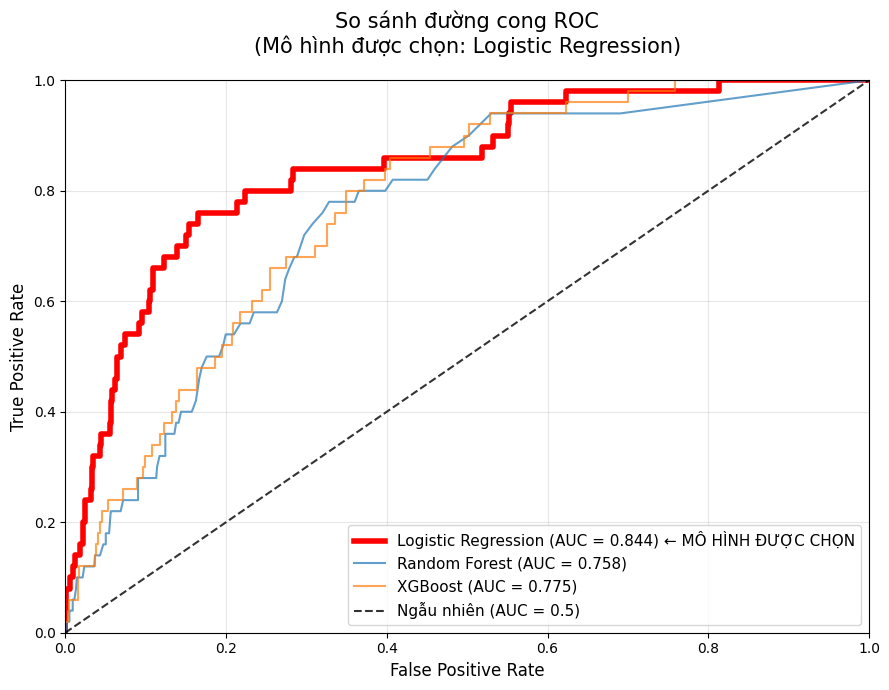

ROC-AUC của mô hình chính (Logistic + SMOTE): 0.8438


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import numpy as np

# Đảm bảo có tập test
if 'X_test' not in globals() or 'y_test' not in globals():
    raise ValueError("Không tìm thấy X_test hoặc y_test. Hãy chạy lại phần train/test split.")

plt.figure(figsize=(9, 7))

possible_names = ['model_lr', 'model_logistic_smote', 'final_model', 'best_model', 
                  'logreg', 'logreg_smote', 'clf', 'model', 'logistic_model', 'logreg_final']

logistic_model = None
model_name_used = None

for name in possible_names:
    if name in globals() and globals()[name] is not None:
        try:
            # Kiểm tra predict_proba
            globals()[name].predict_proba(X_test[:1])
            logistic_model = globals()[name]
            model_name_used = name
            break
        except:
            continue

if logistic_model is None:
    print("Không tự động tìm thấy mô hình Logistic")
    print("Các biến hiện có (có chứa 'model' hoặc 'log'):", 
          [name for name in globals().keys() if not name.startswith('_') and ('model' in name.lower() or 'log' in name.lower() or 'clf' in name)])
    print("\nVui lòng sửa tên biến ở dòng dưới đây:")
    logistic_model = model_lr 


# Vẽ ROC của mô hình chính
y_proba = logistic_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, 
         color='red', linewidth=4,
         label=f'Logistic Regression (AUC = {roc_auc:.3f}) ← MÔ HÌNH ĐƯỢC CHỌN')

for name, model in [('Random Forest', model_rf if 'model_rf' in globals() else None),
                    ('XGBoost', model_xgb if 'model_xgb' in globals() else None)]:
    if model is not None:
        try:
            proba = model.predict_proba(X_test)[:, 1]
            fpr2, tpr2, _ = roc_curve(y_test, proba)
            auc2 = auc(fpr2, tpr2)
            plt.plot(fpr2, tpr2, label=f'{name} (AUC = {auc2:.3f})', alpha=0.7)
        except:
            pass

# Đường chéo ngẫu nhiên
plt.plot([0, 1], [0, 1], 'k--', label='Ngẫu nhiên (AUC = 0.5)', alpha=0.8)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('So sánh đường cong ROC\n(Mô hình được chọn: Logistic Regression)', fontsize=15, pad=20)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# In kết quả AUC để chắc chắn
print(f"ROC-AUC của mô hình chính (Logistic + SMOTE): {roc_auc:.4f}")

## 3.5 Precision-Recall curve cho các model

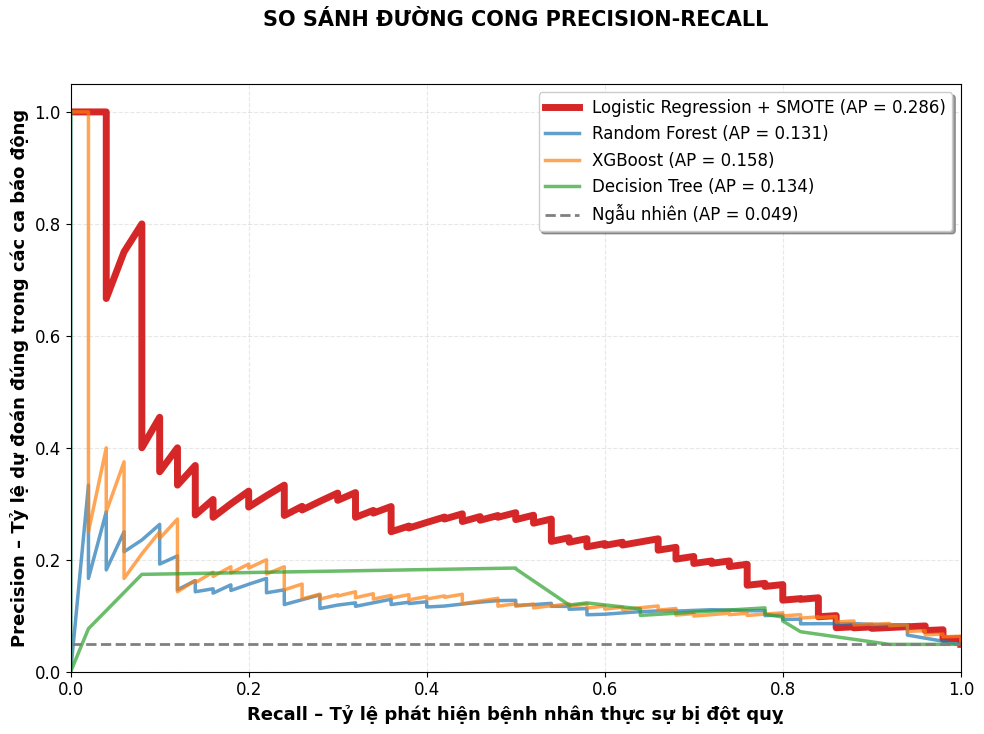

In [ ]:


from sklearn.metrics import precision_recall_curve, average_precision_score, auc
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 7.5))
plt.rcParams['font.size'] = 12

y_proba_lr = model_lr.predict_proba(X_test)[:, 1]
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_proba_lr)
ap_lr = average_precision_score(y_test, y_proba_lr)        # Average Precision
auc_pr_lr = auc(recall_lr, precision_lr)                   # AUC của PR curve

plt.plot(recall_lr, precision_lr,
         color='#d62728', linewidth=5,
         label=f'Logistic Regression + SMOTE (AP = {ap_lr:.3f})')

other_models = {
    'Random Forest': model_rf if 'model_rf' in globals() else None,
    'XGBoost'      : model_xgb if 'model_xgb' in globals() else None,
    'Decision Tree': model_dt if 'model_dt' in globals() else None
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for (name, model), color in zip(other_models.items(), colors):
    if model is not None:
        try:
            proba = model.predict_proba(X_test)[:, 1]
            prec, rec, _ = precision_recall_curve(y_test, proba)
            ap = average_precision_score(y_test, proba)
            plt.plot(rec, prec, color=color, alpha=0.7, linewidth=2.5,
                     label=f'{name} (AP = {ap:.3f})')
        except:
            pass

baseline = y_test.mean()
plt.axhline(y=baseline, color='gray', linestyle='--', linewidth=2,
            label=f'Ngẫu nhiên (AP = {baseline:.3f})')

plt.xlabel('Recall – Tỷ lệ phát hiện bệnh nhân thực sự bị đột quỵ', fontsize=13, fontweight='bold')
plt.ylabel('Precision – Tỷ lệ dự đoán đúng trong các ca báo động', fontsize=13, fontweight='bold')
plt.title('SO SÁNH ĐƯỜNG CONG PRECISION-RECALL\n',
          fontsize=15, fontweight='bold', pad=25)

plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=12, loc='upper right', frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.show()